# Whether or not a patient has a heart desease

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [127]:
# import data
df = pd.read_csv("heart.csv",
                #  header=None
                 )
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [128]:
df.shape

(1025, 14)

In [129]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [130]:
# Format data
# split data
X = df.drop("target", axis=1).copy()
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [131]:
y = df["target"].copy()
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [132]:
X.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
dtype: object

In [133]:
X['cp'].unique()

array([0, 1, 2, 3])

In [134]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [135]:
# One hot encoding
pd.get_dummies(X, columns=["cp"]).head()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,cp_0,cp_1,cp_2,cp_3
0,52,1,125,212,0,1,168,0,1.0,2,2,3,True,False,False,False
1,53,1,140,203,1,0,155,1,3.1,0,0,3,True,False,False,False
2,70,1,145,174,0,1,125,1,2.6,0,0,3,True,False,False,False
3,61,1,148,203,0,1,161,0,0.0,2,1,3,True,False,False,False
4,62,0,138,294,1,1,106,0,1.9,1,3,2,True,False,False,False


In [136]:
X_encoded = pd.get_dummies(X, columns=["cp", "restecg", "slope", "thal"])
X_encoded.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_0,cp_1,cp_2,cp_3,restecg_0,restecg_1,restecg_2,slope_0,slope_1,slope_2,thal_0,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,True,False,False,False,False,True,False,False,False,True,False,False,False,True
1,53,1,140,203,1,155,1,3.1,0,True,False,False,False,True,False,False,True,False,False,False,False,False,True
2,70,1,145,174,0,125,1,2.6,0,True,False,False,False,False,True,False,True,False,False,False,False,False,True
3,61,1,148,203,0,161,0,0.0,1,True,False,False,False,False,True,False,False,False,True,False,False,False,True
4,62,0,138,294,1,106,0,1.9,3,True,False,False,False,False,True,False,False,True,False,False,False,True,False


In [137]:
y.unique()

array([0, 1])

In [138]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, random_state=13)

clf_dt = DecisionTreeClassifier(random_state=13)
clf_dt = clf_dt.fit(X_train, y_train)

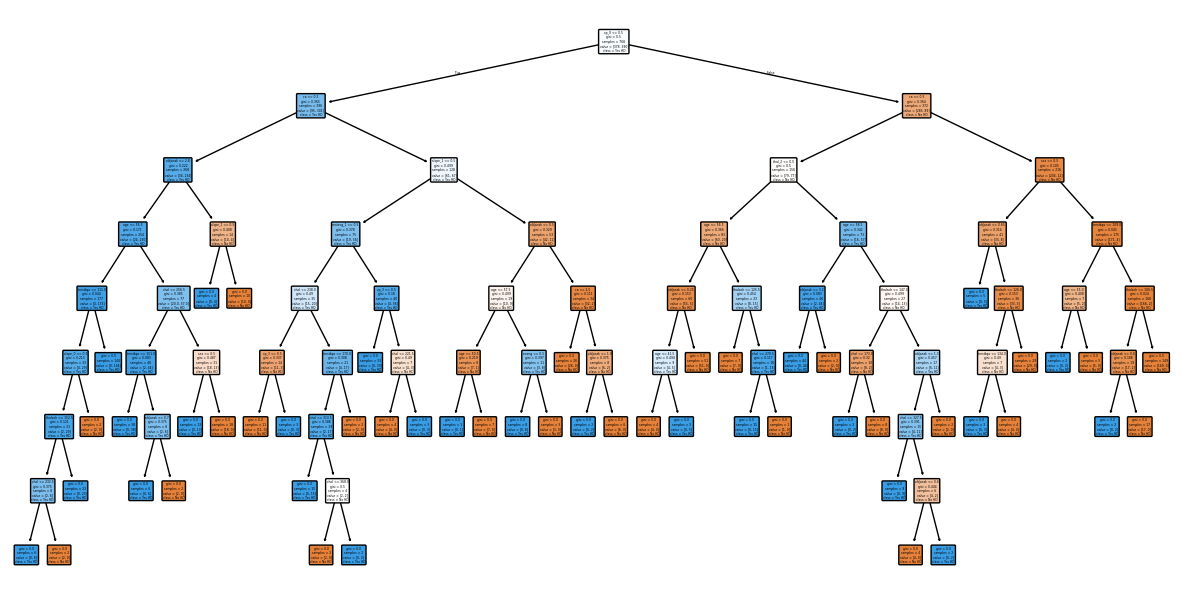

In [139]:
plt.figure(figsize=(15,7.5))
plot_tree(clf_dt,
          filled=True,
          rounded=True,
          class_names=["No HD", "Yes HD"],
          feature_names=X_encoded.columns)
plt.show()

In [140]:
X_test.shape

(257, 23)

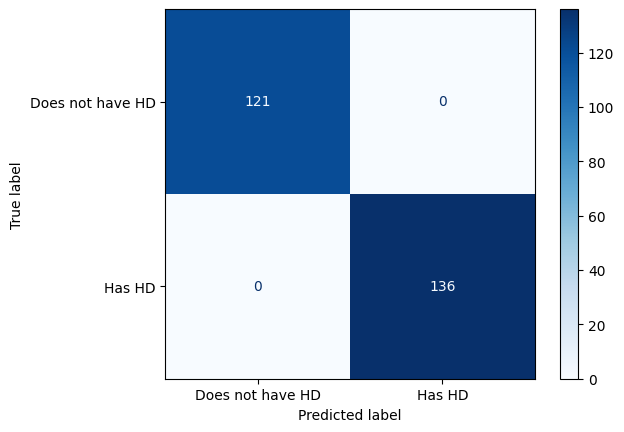

In [141]:
ConfusionMatrixDisplay.from_estimator(clf_dt, X_test, y_test, cmap='Blues',
                                      display_labels=["Does not have HD", "Has HD"])
plt.show()

In [142]:
# Cost Complexity Pruning Part 1: Visualize alpth
path = clf_dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas = ccp_alphas[:-1]

clf_dts = []
for ccp_alpha in ccp_alphas:
    clf_dt = DecisionTreeClassifier(random_state=13, ccp_alpha=ccp_alpha)
    clf_dt.fit(X_train, y_train)
    clf_dts.append(clf_dt)

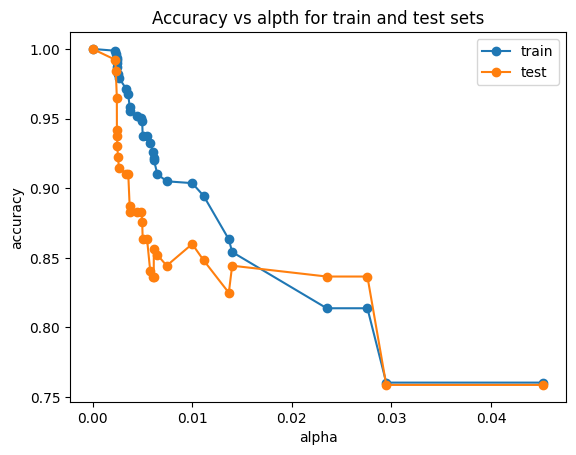

In [143]:
train_scores = [clf_dt.score(X_train, y_train) for clf_dt in clf_dts]
test_scores = [clf_dt.score(X_test, y_test) for clf_dt in clf_dts]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpth for train and test sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train")
ax.plot(ccp_alphas, test_scores, marker='o', label="test")
ax.legend()
plt.show()

In [144]:
clf_dt = DecisionTreeClassifier(random_state=13, ccp_alpha=0.016)

scores = cross_val_score(clf_dt, X_train, y_train, cv=5)
df = pd.DataFrame(data={"tree": range(5), "accuracy": scores})
df

,tree,accuracy
0,0,0.824675
1,1,0.850649
2,2,0.837662
3,3,0.803922
4,4,0.830065


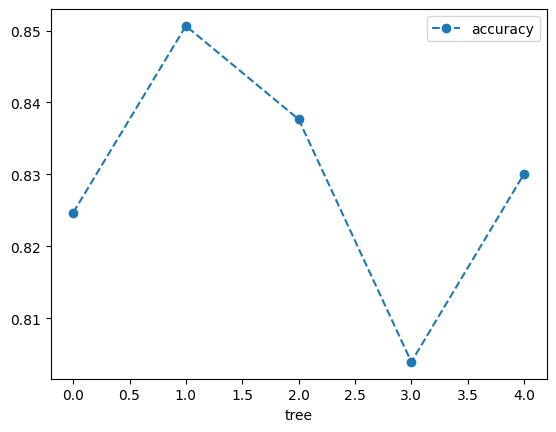

In [145]:
df.plot(x="tree", y="accuracy", marker='o', linestyle='--')
plt.show()

In [146]:
ideal_ccp_alpha = 0.014224

In [147]:
clf_dt_pruned = DecisionTreeClassifier(random_state=13, ccp_alpha=ideal_ccp_alpha)
clf_dt_pruned = clf_dt_pruned.fit(X_train, y_train)

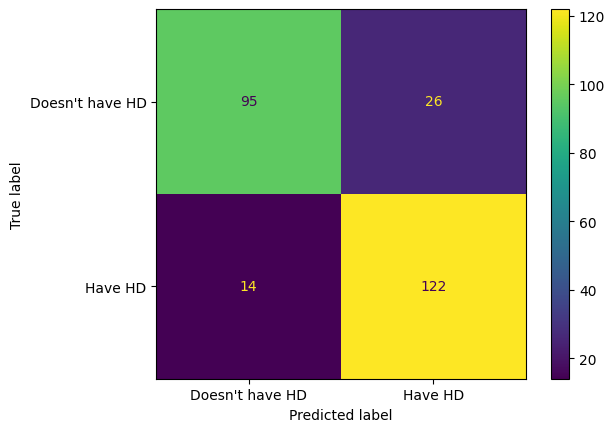

In [ ]:
ConfusionMatrixDisplay.from_estimator(clf_dt_pruned, X_test, y_test,
                                      display_labels=["Doesn't have HD", "Have HD"])
plt.show()

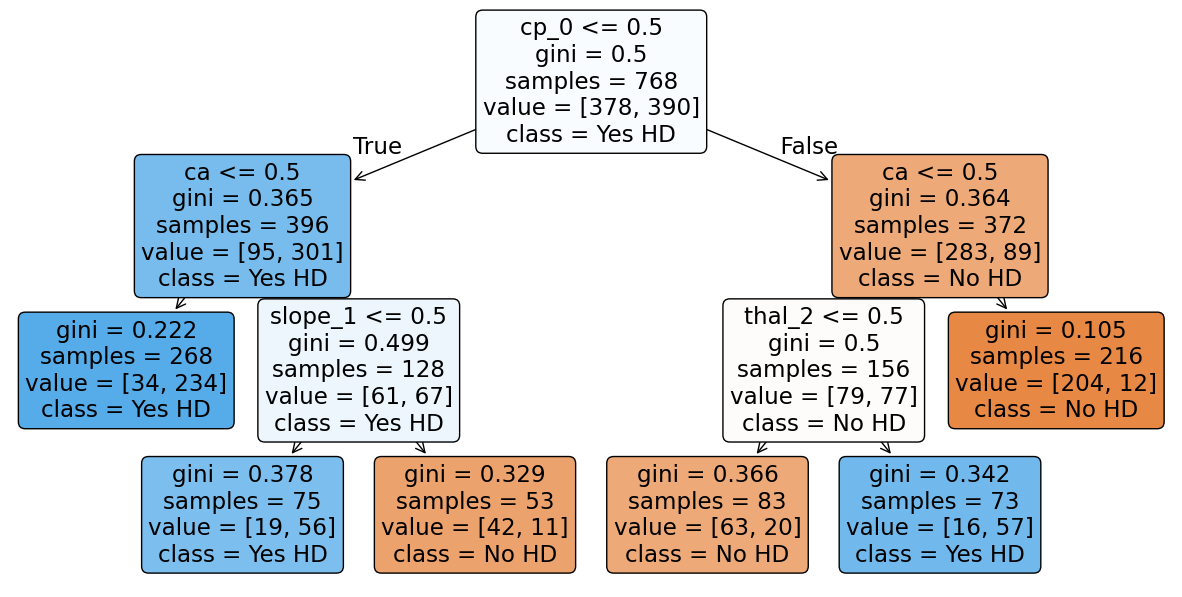

In [154]:
plt.figure(figsize=(15,7.5))
plot_tree(clf_dt_pruned,
          filled=True,
          rounded=True,
          class_names=["No HD", "Yes HD"],
          feature_names=X_encoded.columns)
plt.show()